# LUNA16 — EDA, preprocesamiento y pipeline MONAI

Análisis exploratorio y visualización del **mismo flujo** que [`LUNA16_R3D18_Training.ipynb`](LUNA16_R3D18_Training.ipynb): ingesta del zip, etiquetas *scan-level*, estadísticas de CT, figuras paso a paso (SimpleITK + PyTorch) y un `Compose` MONAI equivalente.

**Documentación detallada:** [LUNA16_EDA_Preprocessing_Explicacion.md](LUNA16_EDA_Preprocessing_Explicacion.md)

---

## Contenido

1. Setup y rutas (Google Drive).
2. Descompresión de `Luna16 Lung Cancer Dataset.zip`.
3. Tabla `df_labels` (888 escaneos + `annotations.csv`).
4. EDA: balance, spacing/tamaño, histogramas HU.
5. Visualización del pipeline de producción (cortes ortogonales en cada paso).
6. Pipeline MONAI y comparación MAE frente al tensor 64³ SITK.
7. Limitaciones y referencia al entrenamiento R3D-18.


## 1. Entorno Colab

Mismas dependencias y convención de rutas que el notebook de entrenamiento del Experto 4. Ejecutar en **Google Colab** con el zip del dataset en `01_Data/Raw/` (o ajustar `RAW_DIR`).


In [1]:
# Fase 0: dependencias, Drive y rutas (alineado a LUNA16_R3D18_Training.ipynb)
!pip install -q SimpleITK nibabel monai scikit-learn tqdm seaborn scipy matplotlib-inline

from google.colab import drive
import os, glob, time, json, shutil, subprocess, random
import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib as mpl
try:
    mpl.use("module://matplotlib_inline.backend_inline")
except Exception:
    try:
        __import__("IPython").get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

RAW_DIR = '/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/'
LOCAL_DEST = '/content/datasets/'
LUNA_ZIP_NAME = 'Luna16 Lung Cancer Dataset.zip'
LUNA_FOLDER_NAME = os.path.splitext(LUNA_ZIP_NAME)[0]
LUNA_BASE = os.path.join(LOCAL_DEST, LUNA_FOLDER_NAME)

os.makedirs(LOCAL_DEST, exist_ok=True)
print('Rutas:')
print(f'  Zip en Drive: {os.path.join(RAW_DIR, LUNA_ZIP_NAME)}')
print(f'  Destino local esperado: {LUNA_BASE}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 61.5 MB/s eta 0:00:00
Mounted at /content/drive
Rutas:
  Zip en Drive: /content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/Luna16 Lung Cancer Dataset.zip
  Destino local esperado: /content/datasets/Luna16 Lung Cancer Dataset


### 1.1 Ingesta: copia del zip y descompresión

Idéntico al protocolo del notebook de entrenamiento: copia a `/content/datasets/`, `unzip` (fallback `zipfile`), borrado del zip local para ahorrar espacio.


In [2]:
# Fase 1: descompresión (mismo código que LUNA16_R3D18_Training.ipynb)
FORCE_REUNZIP = False  # True para forzar descompresión aunque existan .mhd

drive_zip_path = os.path.join(RAW_DIR, LUNA_ZIP_NAME)
if not os.path.isfile(drive_zip_path):
    alt = sorted(
        glob.glob(os.path.join(RAW_DIR, '*Luna*.zip')) +
        glob.glob(os.path.join(RAW_DIR, '*luna*.zip'))
    )
    if alt:
        drive_zip_path = alt[0]
        print(f"AVISO: usando zip encontrado: {drive_zip_path}")
    else:
        raise FileNotFoundError(
            f"No está {LUNA_ZIP_NAME} en {RAW_DIR}. Sube el zip o ajusta LUNA_ZIP_NAME."
        )

local_zip_path = os.path.join(LOCAL_DEST, os.path.basename(drive_zip_path))
unzip_dir = os.path.join(LOCAL_DEST, os.path.splitext(os.path.basename(drive_zip_path))[0])

mhd_probe = glob.glob(os.path.join(unzip_dir, '**', '*.mhd'), recursive=True)
if FORCE_REUNZIP or len(mhd_probe) < 100:
    print("1. Copiando zip desde Drive al entorno local...")
    t0 = time.time()
    shutil.copy2(drive_zip_path, local_zip_path)
    print(f"   Copia OK ({time.time()-t0:.1f}s)")

    os.makedirs(unzip_dir, exist_ok=True)
    print(f"2. Descomprimiendo en {unzip_dir} ...")
    t1 = time.time()
    r = subprocess.run(
        ['unzip', '-q', '-o', local_zip_path, '-d', unzip_dir],
        capture_output=True, text=True,
    )
    if r.returncode != 0:
        print("unzip falló, intentando zipfile...")
        import zipfile
        with zipfile.ZipFile(local_zip_path, 'r') as zf:
            zf.extractall(unzip_dir)
    print(f"   Unzip OK ({time.time()-t1:.1f}s)")

    print("3. Borrando zip local...")
    os.remove(local_zip_path)
else:
    print(f"Datos ya presentes en {unzip_dir} ({len(mhd_probe)} .mhd). "
          f"Pon FORCE_REUNZIP=True para volver a extraer.")

LUNA_BASE = unzip_dir

mhd_files = sorted(glob.glob(os.path.join(LUNA_BASE, '**', '*.mhd'), recursive=True))
raw_files = sorted(
    glob.glob(os.path.join(LUNA_BASE, '**', '*.raw'), recursive=True)
    + glob.glob(os.path.join(LUNA_BASE, '**', '*.zraw'), recursive=True)
)
csv_files = sorted(glob.glob(os.path.join(LUNA_BASE, '**', '*.csv'), recursive=True))

print(f"\nArchivos bajo {LUNA_BASE}:")
print(f"  .mhd: {len(mhd_files)}")
print(f"  .raw/.zraw: {len(raw_files)}")
print(f"  .csv: {len(csv_files)}")
for c in csv_files:
    print(f"    {c}")


1. Copiando zip desde Drive al entorno local...
   Copia OK (4.5s)
2. Descomprimiendo en /content/datasets/Luna16 Lung Cancer Dataset ...
   Unzip OK (5.5s)
3. Borrando zip local...

Archivos bajo /content/datasets/Luna16 Lung Cancer Dataset:
  .mhd: 888
  .raw/.zraw: 888
  .csv: 10
    /content/datasets/Luna16 Lung Cancer Dataset/annotations.csv
    /content/datasets/Luna16 Lung Cancer Dataset/candidates.csv
    /content/datasets/Luna16 Lung Cancer Dataset/candidates_V2/candidates_V2.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/annotations/annotations.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/annotations/annotations_excluded.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/annotations/seriesuids.csv
    /content/datasets/Luna16 Lung Cancer Dataset/evaluationScript/evaluationScript/exampleFiles/evaluation/froc_gt_prob_vectors_sampleSubmission.csv
    /content/dat

## 2. Etiquetas scan-level

**Regla (Experto 4):** positivo = `seriesuid` aparece en `annotations.csv`; negativo = resto de escaneos entre los `.mhd`. No se usan `candidates*.csv`.


In [3]:
# Fase 2: df_labels — misma lógica que el entrenamiento

def _normalize_luna_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    lower = {c.lower(): c for c in df.columns}
    ren = {}
    if 'seriesuid' not in lower and 'seriesinstanceuid' in lower:
        ren[lower['seriesinstanceuid']] = 'seriesuid'
    for old, new in ren.items():
        df = df.rename(columns={old: new})
    return df


ann_path = os.path.join(LUNA_BASE, 'annotations.csv')
if not os.path.isfile(ann_path):
    ann_path = next((c for c in csv_files if 'annotations' in os.path.basename(c).lower()
                     and 'excluded' not in os.path.basename(c).lower()), None)

if ann_path is None or not os.path.isfile(str(ann_path)):
    raise FileNotFoundError("No se encontró annotations.csv en el dataset descomprimido.")

annotations = pd.read_csv(ann_path)
annotations = _normalize_luna_columns(annotations)
if 'seriesuid' not in annotations.columns:
    raise ValueError("annotations.csv debe contener la columna 'seriesuid'.")

annotations['seriesuid'] = annotations['seriesuid'].astype(str).str.strip()
positive_uids = set(annotations['seriesuid'].values)

rows = []
for mhd in sorted(mhd_files):
    uid = os.path.splitext(os.path.basename(mhd))[0]
    uid_s = str(uid).strip()
    rows.append({
        'seriesuid': uid_s,
        'mhd_path': mhd,
        'label': 1 if uid_s in positive_uids else 0,
        'group_id': uid_s,
    })

df_labels = pd.DataFrame(rows)
df_labels = df_labels.dropna(subset=['mhd_path'])

print(f"annotations.csv: {ann_path}")
print(f"Filas en annotations (nódulos): {len(annotations)}")
print(f"Series UID únicos en annotations: {len(positive_uids)}")
print(f"\nMuestras scan-level: {len(df_labels)}")
print(df_labels['label'].value_counts())
print(f"group_id únicos: {df_labels['group_id'].nunique()}")


annotations.csv: /content/datasets/Luna16 Lung Cancer Dataset/annotations.csv
Filas en annotations (nódulos): 1186
Series UID únicos en annotations: 601

Muestras scan-level: 888
label
1    601
0    287
Name: count, dtype: int64
group_id únicos: 888


## 3. EDA tabular y estadístico de CT

Se limita el barrido con `MAX_SCANS_FOR_STATS` para tiempo/RAM en Colab. Ajusta a `888` o `len(df_labels)` para estadísticas completas (más lento).


Meta CT:   0%|          | 0/100 [00:00<?, ?it/s]

Muestreo HU:   0%|          | 0/8 [00:00<?, ?it/s]

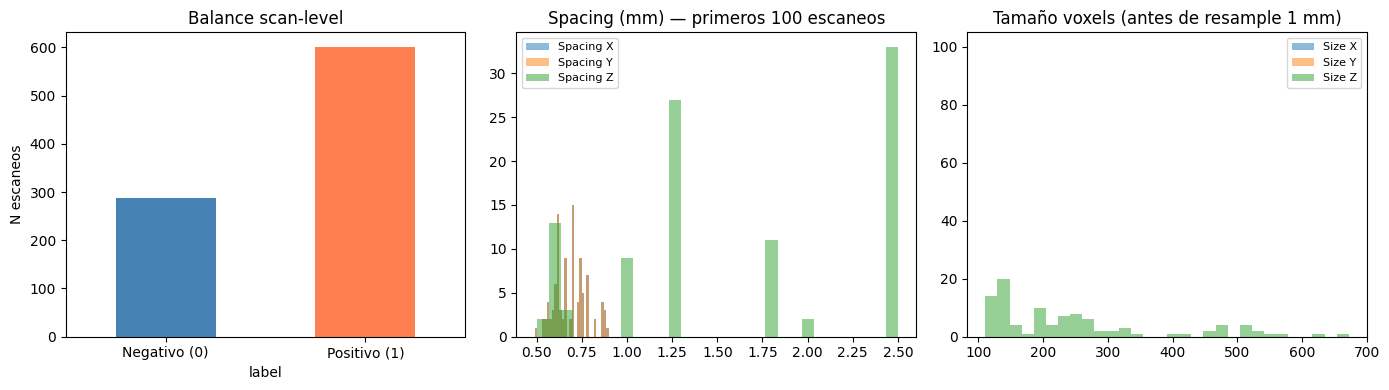

Spacing (mm): mediana por eje [0.69238299 0.69238299 1.25      ]
Size (vox): mediana por eje [512.  512.  211.5]


In [4]:
# Hiperparámetros de ventana HU (iguales al entrenamiento)
HU_MIN, HU_MAX = -1000.0, 400.0
VOL_SIZE = (64, 64, 64)

MAX_SCANS_FOR_STATS = 100  # sube a len(df_labels) para todos los escaneos
MAX_HU_VOLUMES = 8  # para histograma HU en crudo
HU_SUBSAMPLE = 20000  # voxeles aleatorios por volumen (submuestreo)

rng = np.random.default_rng(SEED)


def collect_meta_and_hu(df, max_scans, max_hu_vol, hu_sub):
    spacing_xyz = []
    size_xyz = []
    hu_raw_samples = {0: [], 1: []}

    subset = df.head(max_scans)
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc='Meta CT'):
        img = sitk.ReadImage(row['mhd_path'])
        spacing_xyz.append(np.array(img.GetSpacing(), dtype=np.float64))
        size_xyz.append(np.array(img.GetSize(), dtype=np.int64))

    hu_df = df.head(max_hu_vol)
    for _, row in tqdm(hu_df.iterrows(), total=len(hu_df), desc='Muestreo HU'):
        img = sitk.ReadImage(row['mhd_path'])
        arr = sitk.GetArrayFromImage(img).astype(np.float32).ravel()
        if arr.size > hu_sub:
            idx = rng.choice(arr.size, size=hu_sub, replace=False)
            arr = arr[idx]
        lbl = int(row['label'])
        hu_raw_samples[lbl].append(arr)

    return np.stack(spacing_xyz), np.stack(size_xyz), hu_raw_samples


spac, sizes, hu_by_label = collect_meta_and_hu(df_labels, MAX_SCANS_FOR_STATS, MAX_HU_VOLUMES, HU_SUBSAMPLE)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df_labels['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_xticklabels(['Negativo (0)', 'Positivo (1)'], rotation=0)
axes[0].set_title('Balance scan-level')
axes[0].set_ylabel('N escaneos')

for j, name in enumerate(['Spacing X', 'Spacing Y', 'Spacing Z']):
    axes[1].hist(spac[:, j], bins=30, alpha=0.5, label=name)
axes[1].legend(fontsize=8)
axes[1].set_title(f'Spacing (mm) — primeros {MAX_SCANS_FOR_STATS} escaneos')

for j, name in enumerate(['Size X', 'Size Y', 'Size Z']):
    axes[2].hist(sizes[:, j], bins=30, alpha=0.5, label=name)
axes[2].legend(fontsize=8)
axes[2].set_title('Tamaño voxels (antes de resample 1 mm)')

plt.tight_layout()
plt.show()

print('Spacing (mm): mediana por eje', np.median(spac, axis=0))
print('Size (vox): mediana por eje', np.median(sizes, axis=0))


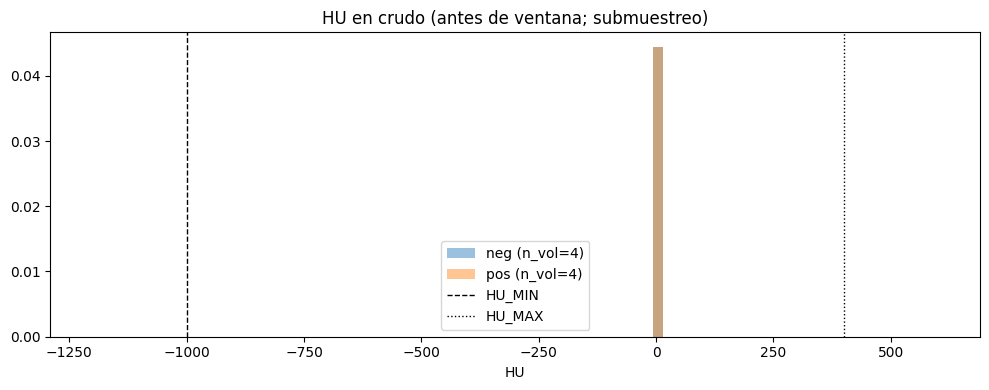

In [5]:
# Histogramas HU en crudo (submuestreo) por etiqueta
fig, ax = plt.subplots(figsize=(10, 4))
for lbl, name in [(0, 'neg'), (1, 'pos')]:
    if not hu_by_label[lbl]:
        continue
    h = np.concatenate(hu_by_label[lbl])
    ax.hist(h, bins=80, density=True, alpha=0.45, label=f'{name} (n_vol={len(hu_by_label[lbl])})', range=(-1200, 600))
ax.axvline(HU_MIN, color='k', ls='--', lw=1, label='HU_MIN')
ax.axvline(HU_MAX, color='k', ls=':', lw=1, label='HU_MAX')
ax.set_xlabel('HU')
ax.set_title('HU en crudo (antes de ventana; submuestreo)')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Pipeline de producción (SimpleITK + PyTorch)

Réplica de `extract_full_volume_64_np` y `volume_1ch_to_kinetics_3ch` del entrenamiento. Se guardan tensores intermedios para visualizar **cortes ortogonales** (eje Z, Y, X) en el centro del volumen.

Orden: **1 mm isotrópico** → clip HU → **[0,1]** → **trilineal 64³** → repetir a 3 canales → z-score **Kinetics-400**.



=== POS 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860 ===


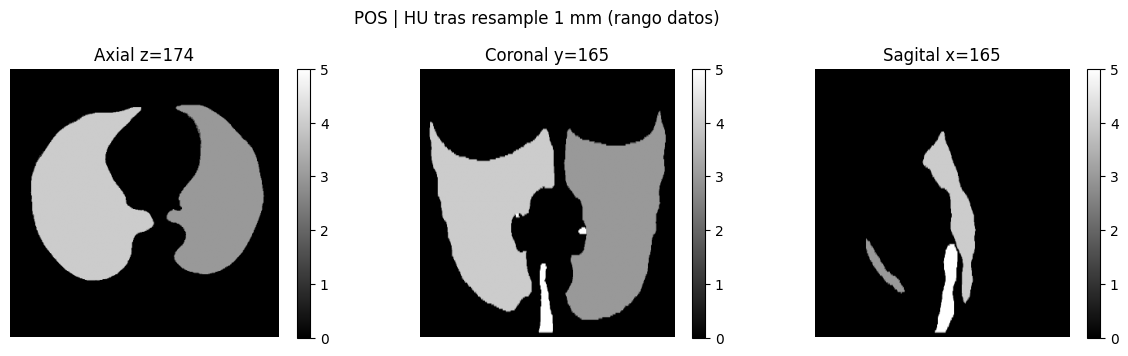

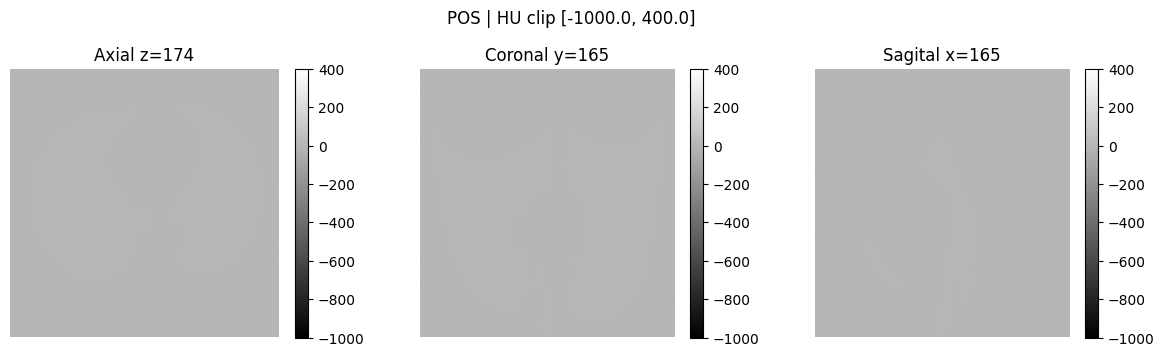

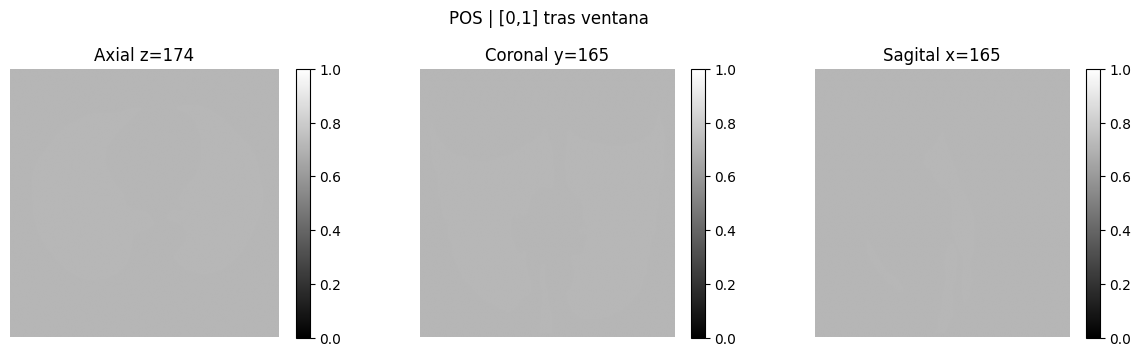

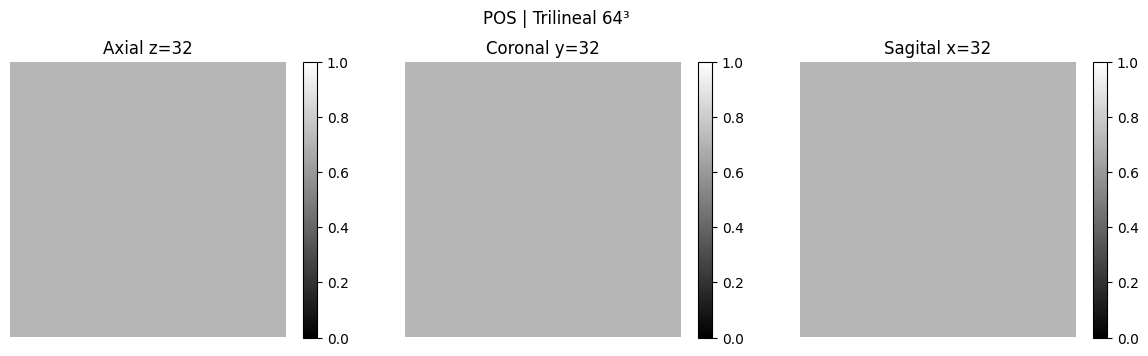

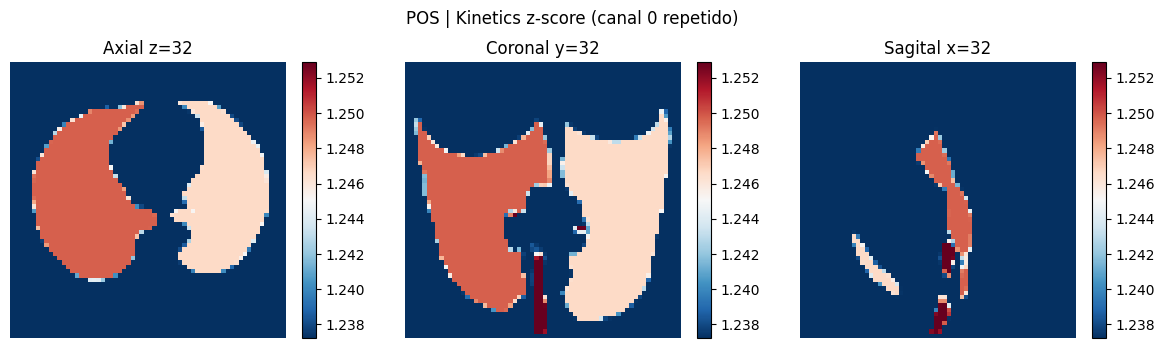

shape kinetics: (3, 64, 64, 64) min/max: 1.2372307777404785 1.5733845233917236

=== NEG 1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840553388986847034053 ===


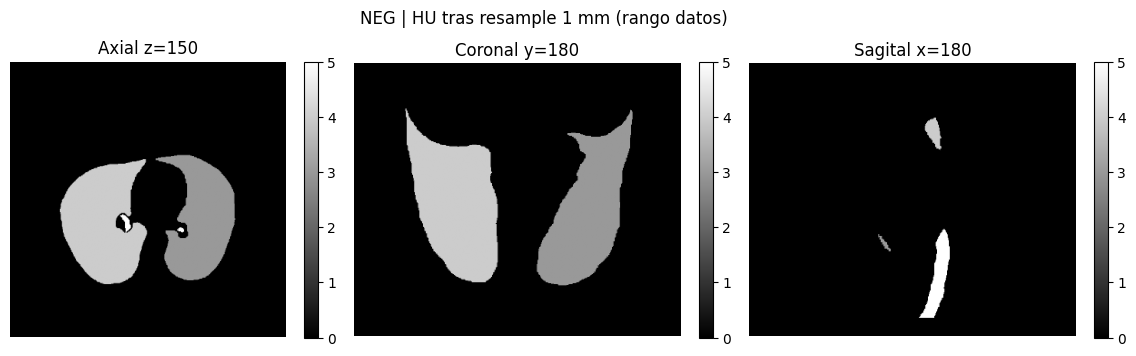

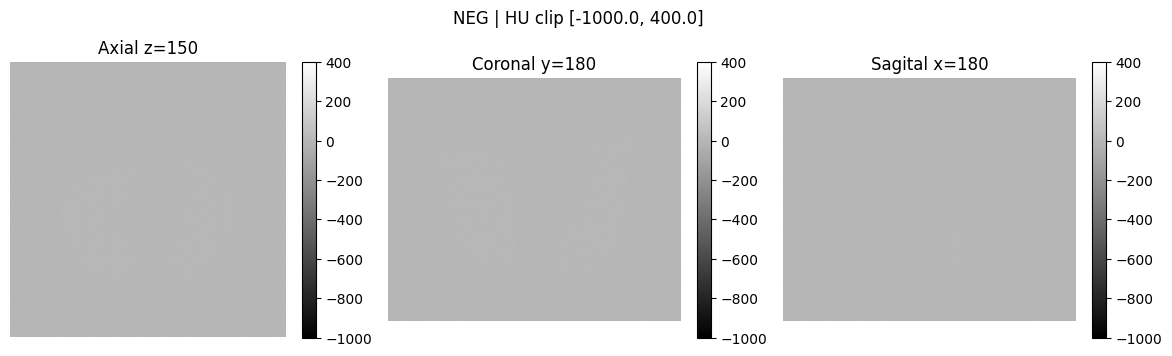

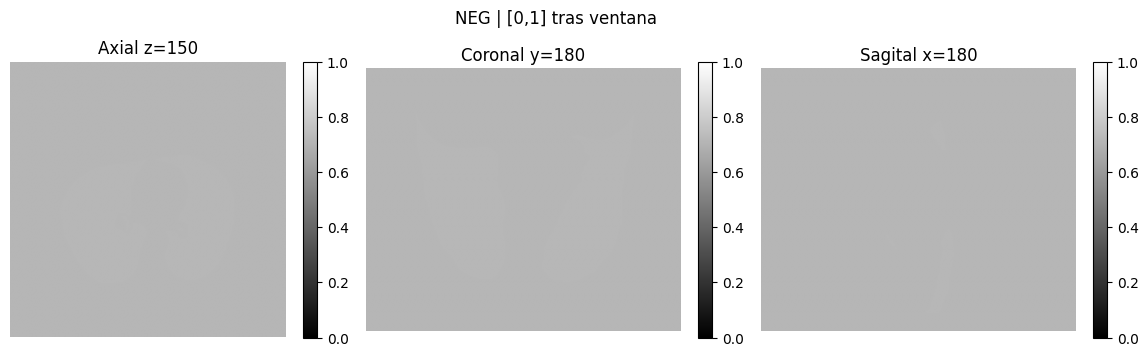

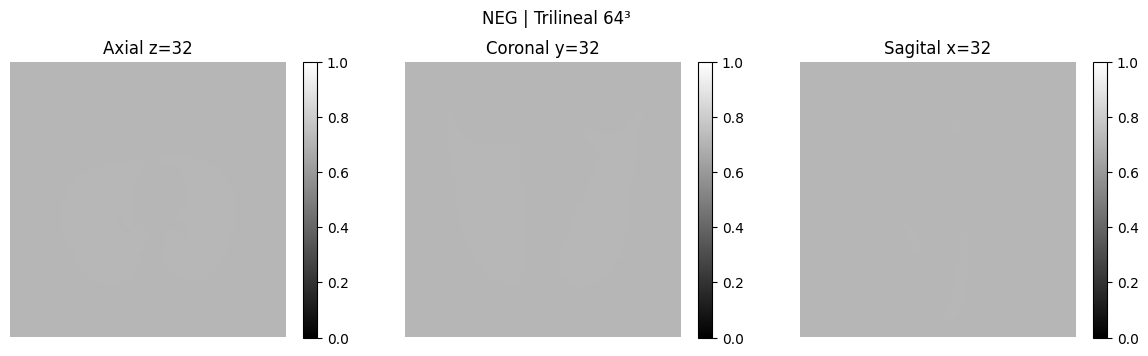

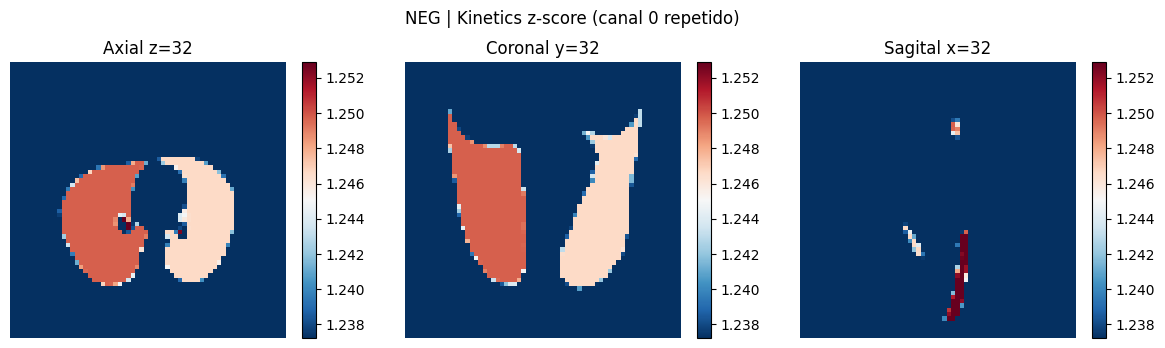

shape kinetics: (3, 64, 64, 64) min/max: 1.2372307777404785 1.5733845233917236


In [6]:
# Constantes Kinetics-400 (R3D-18)
KINETICS_MEAN = torch.tensor([0.43216, 0.394666, 0.37645]).view(3, 1, 1, 1)
KINETICS_STD = torch.tensor([0.22803, 0.22145, 0.216989]).view(3, 1, 1, 1)


def volume_1ch_to_kinetics_3ch(vol_64):
    t = torch.from_numpy(np.ascontiguousarray(vol_64)).float()
    t = t.unsqueeze(0).expand(3, -1, -1, -1)
    mean = KINETICS_MEAN.to(device=t.device, dtype=t.dtype)
    std = KINETICS_STD.to(device=t.device, dtype=t.dtype)
    return (t - mean) / std


def pipeline_sitk_intermediates(row):
    'Devuelve dict con pasos para visualización y comparación MONAI.'
    mhd_path = row['mhd_path']
    img = sitk.ReadImage(mhd_path)
    orig_spacing = np.array(img.GetSpacing())
    orig_size = np.array(img.GetSize())
    new_spacing = np.array([1.0, 1.0, 1.0])
    new_size = (orig_size * orig_spacing / new_spacing).astype(int).tolist()

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing.tolist())
    resampler.SetSize(new_size)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetOutputDirection(img.GetDirection())
    img_iso = resampler.Execute(img)

    vol_hu = sitk.GetArrayFromImage(img_iso).astype(np.float32)
    vol_clip = np.clip(vol_hu, HU_MIN, HU_MAX)
    vol_01 = (vol_clip - HU_MIN) / (HU_MAX - HU_MIN)

    t = torch.from_numpy(vol_01).float().unsqueeze(0).unsqueeze(0)
    t64 = F.interpolate(t, size=VOL_SIZE, mode='trilinear', align_corners=False)
    vol_64 = t64.squeeze(0).squeeze(0).numpy().astype(np.float32)

    tensor_k = volume_1ch_to_kinetics_3ch(vol_64)
    return {
        'orig_spacing': orig_spacing,
        'orig_size': orig_size,
        'hu_iso': vol_hu,
        'clip': vol_clip,
        '01': vol_01,
        '64': vol_64,
        'kinetics': tensor_k,
    }


def plot_orthogonal_slices(vol, title, cmap='gray', vmin=None, vmax=None):
    'vol: numpy 3D (z,y,x) como sitk.GetArrayFromImage.'
    if vol.ndim != 3:
        raise ValueError('Se espera volumen 3D')
    zc, yc, xc = [s // 2 for s in vol.shape]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    slices = [vol[zc, :, :], vol[:, yc, :], vol[:, :, xc]]
    titles = [f'Axial z={zc}', f'Coronal y={yc}', f'Sagital x={xc}']
    if vmin is None:
        vmin = float(np.nanmin(vol))
    if vmax is None:
        vmax = float(np.nanmax(vol))
    for ax, sl, tt in zip(axes, slices, titles):
        im = ax.imshow(sl, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(tt)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# Un positivo y un negativo (si existen)
pos_rows = df_labels[df_labels['label'] == 1]
neg_rows = df_labels[df_labels['label'] == 0]
sample_pos = pos_rows.iloc[0] if len(pos_rows) else df_labels.iloc[0]
sample_neg = neg_rows.iloc[0] if len(neg_rows) else None

for name, row in [('POS', sample_pos), ('NEG', sample_neg)]:
    if row is None:
        continue
    print('\n===', name, row['seriesuid'], '===')
    P = pipeline_sitk_intermediates(row)

    plot_orthogonal_slices(P['hu_iso'], f'{name} | HU tras resample 1 mm (rango datos)')
    plot_orthogonal_slices(P['clip'], f'{name} | HU clip [{HU_MIN}, {HU_MAX}]', vmin=HU_MIN, vmax=HU_MAX)
    plot_orthogonal_slices(P['01'], f'{name} | [0,1] tras ventana', vmin=0, vmax=1)
    plot_orthogonal_slices(P['64'], f'{name} | Trilineal 64³', vmin=0, vmax=1)

    tk = P['kinetics']
    ch0 = tk[0].numpy()
    plot_orthogonal_slices(ch0, f'{name} | Kinetics z-score (canal 0 repetido)', cmap='RdBu_r')

    print('shape kinetics:', tuple(tk.shape), 'min/max:', float(tk.min()), float(tk.max()))


## 6. Resumen

- **Ingesta:** copia del zip desde Drive y descompresión en `/content/datasets/`.
- **Etiquetas:** 888 escaneos; positivos = presencia de `seriesuid` en `annotations.csv`.
- **Preprocesamiento del modelo:** documentado en el training y replicado aquí con figuras intermedias.
- **MONAI:** pipeline paralelo para validación; **checkpoint / entrenamiento** del MoE usan el pipeline **SimpleITK + torch** del notebook R3D-18.

Tiempo y RAM dependen de `MAX_SCANS_FOR_STATS` y del tamaño del zip; aumentar el muestreo solo cuando sea necesario.
